STARTING POINT


# SACCO Financial Analysis and Surplus Prediction

## Problem Statement

Savings and Credit Cooperative Organizations (SACCOs) play a critical role in Kenya's financial inclusion landscape,
providing affordable credit and savings services to millions of members.
Despite their importance, many SACCOs struggle with financial planning — particularly the ability to forecast
their Current Year Surplus, a key indicator of financial health and operational sustainability.

This project addresses the following problem:

> **Can we predict a SACCO's Current Year Surplus from its balance sheet data,
> and which financial indicators are the strongest drivers of that surplus?**

### Objectives

1. Analyse the financial performance trends of 52 deposit-taking SACCOs regulated by SASRA over the period 2007 to 2023.
2. Identify the key financial indicators that drive Current Year Surplus.
3. Build and compare multiple regression models — from simple baselines to advanced ensemble and neural network approaches.
4. Select the best-performing model and deploy it as an interactive Streamlit web application.

### Why This Matters

Accurate surplus prediction enables SACCO management to:
- Make informed decisions on dividend distribution and reserve allocation
- Identify early warning signs of financial underperformance
- Plan loan portfolio growth in line with available capital
- Comply with SASRA regulatory requirements on capital adequacy

### Dataset

- **Source:** SASRA annual supervision reports, 2007–2023
- **Scope:** 52 deposit-taking SACCOs
- **Target variable:** Current Year's Surplus
- **Features:** 10 balance sheet indicators (Total Assets, Gross Loan Portfolio, Total Equity, etc.)
- **Preprocessing:** Log transformation applied to handle extreme right-skew in financial data

### Modelling Approach

| Stage | Models |
|---|---|
| Baseline | Linear Regression |
| Improved baseline | Log-transformed Linear Regression |
| Regularised | Ridge Regression, Lasso Regression |
| Ensemble | Random Forest, XGBoost, LightGBM, Stacking Ensemble |
| Deep learning | Neural Network (MLPRegressor) |

### LOADING AND DATA CLEANING

Load Cleaned Data

In this step, we load cleaned SACCO financial data.

The data has been standardized into a consistent format:
- Account_Name
- Financial values across years

This ensures consistency and simplifies further analysis.

In [1]:
pip install numpy pandas matplotlib scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
print("All good")

All good


In [3]:
#importing libraries and testing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("All libraries working")

All libraries working


In [4]:
import pandas as pd
import glob

files = glob.glob("data_clean/*.csv")

df_list = []

for file in files:
    df = pd.read_csv(file)
    df_list.append(df)

len(df_list)

52

Combine Cleaned Datasets

After loading all cleaned SACCO datasets, the next step is to combine them into a single dataset.

Each file represents financial data from a different SACCO but follows the same standardized structure:
- Account_Name
- Financial values across years (2019–2022)

By concatenating these datasets:
- We create a unified dataset for analysis
- Enable comparison across multiple SACCOs
- Prepare the data for transformation and modeling

This step ensures that all SACCO data is consolidated into one dataframe for further processing.

In [5]:
df_all = pd.concat(df_list)

df_all.head()

,Account_Name,2019,2020,2021,2022,2012,2013,2014,2015,2016,...,Unnamed: 16375,Unnamed: 16376,Unnamed: 16377,Unnamed: 16378,Unnamed: 16379,Unnamed: 16380,Unnamed: 16381,Unnamed: 16382,Unnamed: 16383,Unnamed: 12
0,Total Assets,269371213.0,2.934117e+08,369437115.0,403387182.7,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total Deposit liabilities,221613427.0,2.577053e+08,296337292.0,320546208.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total Equity,33585269.0,3.528895e+07,53706746.0,63405036.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total Liabilities,235786131.0,2.581184e+08,315730368.0,339982145.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cash & Cash Equivalent,10834463.0,6.094258e+07,56687339.0,77254741.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Handling Missing Values (Zeroes)

Some financial values were recorded as zeroes but represented missing data.

To address this:
- Data was cleaned to ensure proper numeric formatting
- Columns were converted to numeric format in Python
- Zero values were replaced with missing values (NaN)

This ensures accurate representation of financial data and prevents misleading analysis.

In this dataset, zero values were not treated as legitimate observations but as placeholders for missing financial data. Because of this, replacing them with the median would have introduced misleading information.
Many machine learning models and statistical methods handle missing values more appropriately than incorrectly imputed values.

Accurate handling of missing values is critical, as improper treatment can distort model predictions and reduce reliability.

In [6]:
"""
Converting Data to Numeric Format

All financial columns were converted to numeric format using `pd.to_numeric()`.

The parameter `errors='coerce'` ensures that any non-numeric or invalid values (such as text or corrupted entries) are automatically converted into missing values (`NaN`).

This step is essential for preparing the dataset for analysis and machine learning, as models require numerical input.

"""
df_all.iloc[:, 1:] = df_all.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

In [7]:
"""
All zero values were replaced with `NaN` using the `.mask()` function.

"""
df_all.iloc[:, 1:] = df_all.iloc[:, 1:].mask(df_all.iloc[:, 1:] == 0)

### Reshaping Data to Long Format

The combined dataset is initially in a wide format, where each year is represented as a separate column.

To prepare the data for analysis and machine learning, it is reshaped into a long format using the `melt()` function.

This transformation:

- Converts multiple year columns into a single Year variable  
- Consolidates financial values into a single Value column  
- Preserves the Account_Name as an identifier  

The resulting structure improves consistency and enables easier:

- Time-based analysis  
- Feature engineering  
- Model training  

The final dataset contains:
- Account_Name: type of financial metric  
- Year: time period  
- Value: corresponding financial value  

In [8]:
df_long = df_all.melt(
    id_vars=['Account_Name'],
    var_name='Year',
    value_name='Value'
)

df_long.head()

,Account_Name,Year,Value
0,Total Assets,2019,269371213.0
1,Total Deposit liabilities,2019,221613427.0
2,Total Equity,2019,33585269.0
3,Total Liabilities,2019,235786131.0
4,Cash & Cash Equivalent,2019,10834463.0


"""
### Data Type Validation


A validation check was performed on the `Value` column to confirm that all entries are in numeric format.

Machine learning models require numerical inputs and cannot process non-numeric data types.

The results show that all 9,724 entries are of type `float`, confirming successful data conversion and consistency across the dataset.

This also verifies that earlier preprocessing steps (such as coercion and handling of invalid entries) were effective.

Ensuring correct data types at this stage prevents errors during modeling and guarantees reliable computations in subsequent analysis.
"""

In [9]:
##df_long['Value'].apply(type).value_counts()

Create Modeling Dataset with SACCO and Year

The dataset includes multiple SACCOs with varying time coverage.

To preserve data integrity and avoid mixing financial data across different SACCOs:
- A SACCO identifier is included
- Both SACCO and Year are used as unique identifiers

The dataset is reshaped into a wide format where:
- Each row represents a SACCO at a specific year
- Each column represents a financial feature (e.g., Total Assets, Loans, Equity)
- Values correspond to financial amounts

This structure ensures accurate analysis and supports predictive modeling.

In [10]:
import os
import pandas as pd

df_list = []

for file in files:
    df = pd.read_csv(file)
    
    # clean columns immediately
    df.columns = df.columns.str.strip()
    
    # remove unnamed columns
    df = df.loc[:, ~df.columns.str.contains('Unnamed')]
    
    # extract SACCO name
    sacco_name = os.path.splitext(os.path.basename(file))[0]
    
    # assign SACCO
    df['SACCO'] = sacco_name
    
    df_list.append(df)

df_all = pd.concat(df_list, ignore_index=True)

In [11]:
#confirming the sacco names
df_all[['SACCO']].head()

,SACCO
0,ACUMEN SACCO
1,ACUMEN SACCO
2,ACUMEN SACCO
3,ACUMEN SACCO
4,ACUMEN SACCO


In [12]:
#CONFIRMING ALL THE SACCO NAMES
df_all['SACCO'].unique()

array(['ACUMEN SACCO', 'DEFENCE SACCO', 'ECO-PILLAR SACCO', 'EDIS SACCO',
       'FORTITUDE SACCO', 'GOLDEN PILLAR SACCO', 'GOODFAITH SACCO',
       'GOODWAY SACCO', 'HAZINA SACCO', 'HOME BUSINESS SACCO', 'IG SACCO',
       'IMARIKA SACCO', 'JAMII SACCO', 'JUMUIKA SACCO', 'K-PILLAR SACCO',
       'KENYA ACHIEVAS SACCO', 'KENYA BANKERS SACCO', 'KIMISITU SACCO',
       'KOLENGE SACCO', 'KORU SACCO', 'KWETU SACCO', 'KWIKAS SACCO',
       'LAINISHA SACCO', 'MAFANIKIO SACCO', 'MAGADI SACCO',
       'MAGEREZA SACCO', 'MENTOR SACCO', 'NYATI SACCO', 'PATNAS SACCO',
       'PRIMETIME SACCO', 'SIMBA CHAI SACCO', 'SIRAJI SACCO',
       'SMART LIFE SACCO', 'SOTICO SACCO', 'STIMA SACCO',
       'STRATEGIC DT SACCO', 'TABASAMU SACCO', 'TEMBO SACCO',
       'TOWER RETURNS', 'TRANS COUNTIES SACCO',
       'TRANS NATIONAL TIMES SACCO', 'UNAITAS SACCO',
       'UNITED NATIONS SACCO', 'VIKTAS SACCO', 'VISION AFRICA SACCO',
       'VISION POINT SACCO', 'WAKULIMA COMMERCIAL SACCO',
       'WANAANGA SACCO',

In [13]:
#confirming the number of saccos captured, we had 52 files
df_all['SACCO'].nunique()

52

In [14]:
#checking if sacco name is present on the wide format
df_all.head()

,Account_Name,2019,2020,2021,2022,SACCO,2012,2013,2014,2015,2016,2017,2018,2023,2011,2007,2008,2009,2010
0,Total Assets,269371213.0,2.934117e+08,369437115.0,403387182.7,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Total Deposit liabilities,221613427.0,2.577053e+08,296337292.0,320546208.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Total Equity,33585269.0,3.528895e+07,53706746.0,63405036.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Total Liabilities,235786131.0,2.581184e+08,315730368.0,339982145.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Cash & Cash Equivalent,10834463.0,6.094258e+07,56687339.0,77254741.0,ACUMEN SACCO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
#checking the columns
df_all.columns

Index(['Account_Name', '2019', '2020', '2021', '2022', 'SACCO', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2023', '2011', '2007', '2008',
       '2009', '2010'],
      dtype='object')

In [16]:
#removing the junk columns
df_all = df_all.loc[:, ~df_all.columns.str.contains('Unnamed')]

In [17]:
####Column Selection and Data Cleaning

#In this step, we define a list of relevant columns (`valid_cols`) and filter the dataset to retain only those columns.

valid_cols = ['Account_Name', 'SACCO'] + [...]
valid_cols = ['Account_Name', 'SACCO'] + [
    col for col in df_all.columns if col.isdigit()
]

df_all = df_all[valid_cols]

In [18]:
#confirming the columns
df_all.columns

Index(['Account_Name', 'SACCO', '2019', '2020', '2021', '2022', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2023', '2011', '2007', '2008',
       '2009', '2010'],
      dtype='object')

### Reshaping Data to Long Format

The dataset is currently in a wide format, where each year is represented as a separate column.

To prepare the data for structured analysis, it is reshaped into a long format. This transformation:
- Converts year columns into a single variable
- Retains SACCO identity for each observation
- Creates a consistent structure for time-based analysis

The resulting dataset includes:
- SACCO
- Account_Name
- Year
- Value

In [19]:
df_long = df_all.melt(
    id_vars=['Account_Name', 'SACCO'],
    var_name='Year',
    value_name='Value'
)

In [20]:
df_long[['SACCO']].head()

,SACCO
0,ACUMEN SACCO
1,ACUMEN SACCO
2,ACUMEN SACCO
3,ACUMEN SACCO
4,ACUMEN SACCO


### Data Reshaping for Modeling

To prepare the dataset for modeling, the data was transformed from a long format into a wide format using a pivot table.

- The `SACCO` and `Year` columns were used as identifiers (index), ensuring each row represents a unique SACCO-year combination.
- The `Account_Name` column was converted into multiple feature columns, where each financial metric becomes a separate variable.
- The `Value` column was used as the numerical values for these features.
- Aggregation was performed using the sum function to handle any duplicate entries.

This transformation allows each SACCO's financial indicators (e.g., Total Assets, Loans, Equity) to be represented as individual columns, making the dataset suitable for machine learning models.

After pivoting, the index was reset to convert `SACCO` and `Year` back into standard columns for easier manipulation and analysis.

Finally, the shape and column structure of the dataset were checked to confirm successful transformation and to understand the dimensionality of the modeling dataset.

In [21]:
df_model = df_long.pivot_table(
    index=['SACCO', 'Year'],
    columns='Account_Name',
    values='Value',
    aggfunc='sum'
)

df_model = df_model.reset_index()

df_model.head()

Account_Name,SACCO,Year,Cash & Cash Equivalent,Current Year's Surplus,Financial Investments,Gross Loan Portfolio,Net Loan Portfolio,Share Capital,Statutory Reserve,Total Assets,Total Deposit liabilities,Total Equity,Total Liabilities
0,ACUMEN SACCO,2007,0,0,0,0,0,0,0,0,0,0,0
1,ACUMEN SACCO,2008,0,0,0,0,0,0,0,0,0,0,0
2,ACUMEN SACCO,2009,0,0,0,0,0,0,0,0,0,0,0
3,ACUMEN SACCO,2010,0,0,0,0,0,0,0,0,0,0,0
4,ACUMEN SACCO,2011,0,0,0,0,0,0,0,0,0,0,0


### Dataset Structure Inspection

In this step, the structure of the modeling dataset (`df_model`) was examined by checking its dimensions and reviewing the column names.

The dataset contains identifiers (`SACCO`, `Year`) along with multiple financial features such as Cash & Cash Equivalent, Loan Portfolio, Assets, and Equity.

This inspection confirms that:
- Each column represents a distinct financial variable
- There are no duplicated or redundant columns
- The dataset is properly structured in a wide format suitable for modeling

Understanding the dataset structure at this stage ensures that all features are correctly aligned and helps prevent issues during model training.

In [22]:
df_model.shape
df_model.columns[:50]

Index(['SACCO', 'Year', 'Cash & Cash Equivalent', 'Current Year's Surplus',
       'Financial Investments', 'Gross Loan Portfolio', 'Net Loan Portfolio',
       'Share Capital', 'Statutory Reserve', 'Total Assets',
       'Total Deposit liabilities', 'Total Equity', 'Total Liabilities'],
      dtype='object', name='Account_Name')

Dataset Structure Inspection

In this step, we explore the structure of the modeling dataset (`df_model`) by checking its dimensions and previewing the column names.
We want to ensure no repetition.

Feature Selection

After preparing the dataset, relevant financial variables are selected for modeling.

The target variable is:
- Current Year's Surplus

This represents SACCO performance and is used as a proxy for financial returns.

The selected features include key financial indicators such as:
- Total Assets
- Loan Portfolio
- Deposits
- Equity
- Investments

These variables are expected to influence SACCO performance and are used as predictors in the model.

In [23]:
#Defining the target
y = df_model["Current Year's Surplus"]

In [24]:
#Defining the features
features = [
    'Total Assets',
    'Total Deposit liabilities',
    'Total Equity',
    'Total Liabilities',
    'Cash & Cash Equivalent',
    'Financial Investments',
    'Gross Loan Portfolio',
    'Net Loan Portfolio',
    'Share Capital',
    'Statutory Reserve'
]

X = df_model[features]

In [25]:
#checking missing values
X.isna().sum()

Account_Name
Total Assets                 0
Total Deposit liabilities    0
Total Equity                 0
Total Liabilities            0
Cash & Cash Equivalent       0
Financial Investments        0
Gross Loan Portfolio         0
Net Loan Portfolio           0
Share Capital                0
Statutory Reserve            0
dtype: int64

In [26]:
 df_long['Value'] = (
    df_long['Value']
    .astype(str)  # convert everything to string first
    .str.replace(',', '', regex=True)  # remove commas like 1,000
    .str.replace('-', '', regex=True)  # remove dashes
)

df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

### VISUALIZATIONS

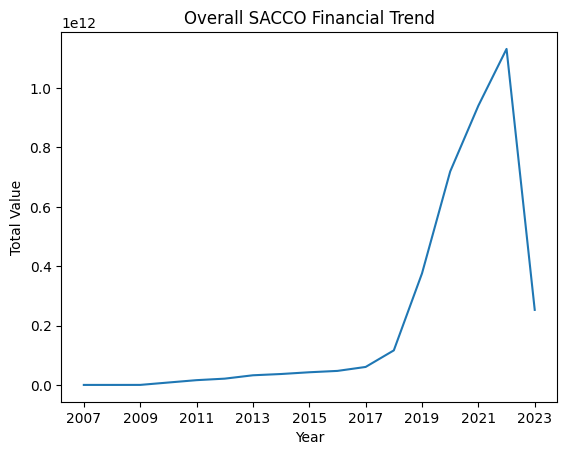

In [27]:
import matplotlib.pyplot as plt

trend = df_long.groupby('Year')['Value'].sum()

plt.figure()
trend.plot()
plt.title('Overall SACCO Financial Trend')
plt.xlabel('Year')
plt.ylabel('Total Value')
plt.show()

Financial performance remained relatively stable from 2007 to 2016, followed by gradual growth between 2017 and 2019. A significant surge occurred between 2019 and 2022, indicating rapid expansion in the sector. However, a sharp decline is observed in 2023, which may be due to incomplete data or external economic factors. Overall, the trend shows strong long-term growth in SACCO performance.

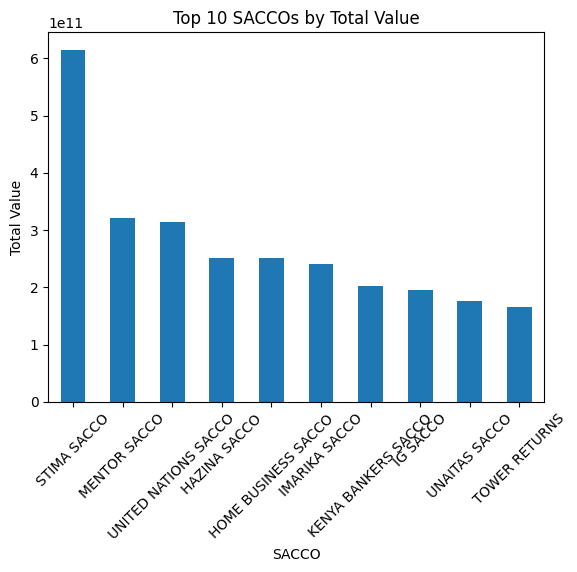

In [28]:
top_saccos = df_long.groupby('SACCO')['Value'].sum().nlargest(10)

plt.figure()
top_saccos.plot(kind='bar')
plt.title('Top 10 SACCOs by Total Value')
plt.xlabel('SACCO')
plt.ylabel('Total Value')
plt.xticks(rotation=45)
plt.show()

The chart highlights a highly concentrated market at the top, where Stima SACCO holds significantly more value than any other institution in the top ten.

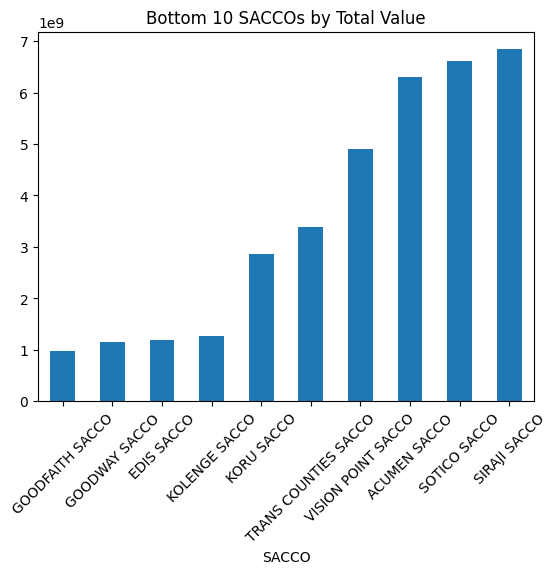

In [29]:
bottom_saccos = df_long.groupby('SACCO')['Value'].sum().nsmallest(10)

plt.figure()
bottom_saccos.plot(kind='bar')
plt.title('Bottom 10 SACCOs by Total Value')
plt.xticks(rotation=45)
plt.show()

This chart identifies the smallest players in the sector, showing a significant valuation gap even within the bottom ten rankings.

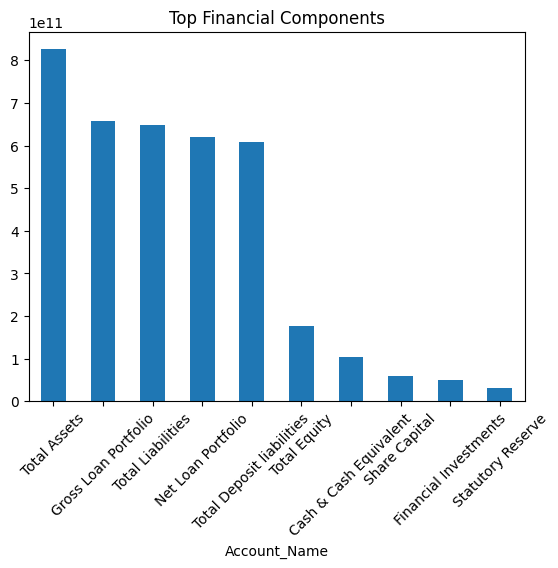

In [30]:
top_accounts = df_long.groupby('Account_Name')['Value'].sum().nlargest(10)

plt.figure()
top_accounts.plot(kind='bar')
plt.title('Top Financial Components')
plt.xticks(rotation=45)
plt.show()

The sector is heavily driven by its loan portfolio, which makes up the bulk of its assets and liabilities. The relatively lower levels of Total Equity and Cash Equivalents compared to the loan volumes highlight a business model deeply focused on credit and leverage.

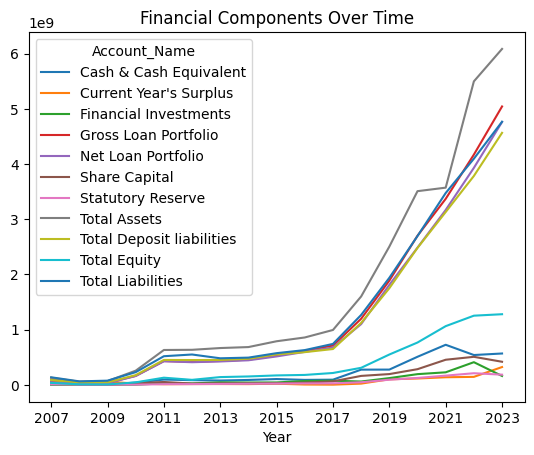

In [31]:
pivot = df_long.pivot_table(
    index='Year',
    columns='Account_Name',
    values='Value'
)

pivot.plot()
plt.title('Financial Components Over Time')
plt.show()

Dominant Growth Drivers: Total Assets  is the clear leader, showing a consistent upward trajectory that accelerates sharply after 2017. Following closely behind are Gross Loan Portfolio, Total Liabilities, and Total Deposit Liabilities, which move in tight synchronization.

The 2017 Inflection Point: Similar to the overall trend, almost all major components remained relatively flat for the first decade. Around 2017–2018, the sector entered a period of aggressive expansion, with assets and loans nearly tripling in value in the subsequent five years.

Correlation of Loans and Liabilities: The near-identical paths of the Loan Portfolio and Total Liabilities suggest that the growth in SACCO assets is heavily funded by member deposits and external debt rather than equity.

Equity and Reserves: While Total Equity  has grown, its pace is much slower than that of assets and liabilities. Smaller components like Statutory Reserves, Share Capital, and Current Year's Surplus remain near the bottom of the scale, showing very modest growth.

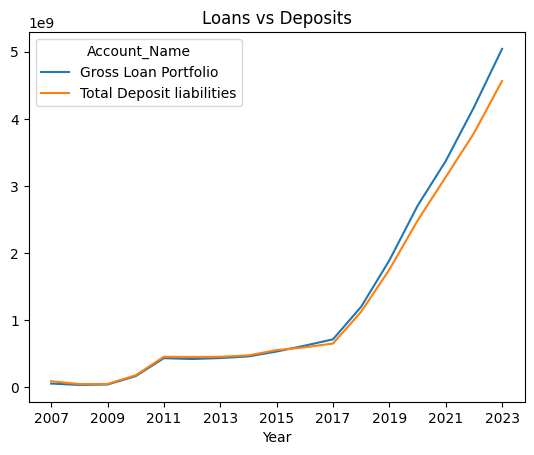

In [32]:
pivot[['Gross Loan Portfolio', 'Total Deposit liabilities']].plot()
plt.title('Loans vs Deposits')
plt.show()

Tight Correlation: Throughout the entire 16-year period, loans and deposits move in almost perfect lockstep. This indicates a very disciplined intermediation model where lending growth is directly fueled by deposit growth.

The Funding Gap: Starting around 2018, a visible gap begins to widen. The Gross Loan Portfolio consistently stays above Total Deposit Liabilities . By 2023, loans have reached approximately 5 billion, while deposits are closer to 4.5 billion.

Loan-to-Deposit Ratio: Because the loan line is higher than the deposit line in recent years, it suggests a loan-to-deposit ratio of over 100%. This means the SACCO is lending out more than it holds in member deposits, likely covering the difference through share capital or external borrowing.

Exponential Acceleration: Both metrics remained below 1 billion for over a decade (2007–2017) before entering a period of aggressive, exponential growth that shows no signs of slowing down by the end of 2023.

### Baseline Model

A baseline regression model is built to predict SACCO performance (Current Year's Surplus) using selected financial indicators.

This provides a starting point for evaluating model performance and understanding relationships between variables.

## Baseline Model: Linear Regression

A Linear Regression model was used as the baseline model for this analysis.

Baseline models provide a simple and interpretable starting point for evaluating model performance.

Linear Regression was selected because:
- It is easy to implement and interpret
- It provides a benchmark for comparison with more complex models
- It helps identify basic relationships between financial variables and SACCO performance

The performance of this model is later compared with more advanced machine learning models.

### Splitting the Dataset

The dataset is divided into training and testing sets to evaluate model performance.

- Training set: used to train the model
- Testing set: used to evaluate model performance on unseen data

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [34]:
X_train.shape, X_test.shape

((707, 10), (177, 10))

### Training the Model

A Linear Regression model is trained using the training dataset.

The model learns relationships between financial indicators and SACCO performance (Current Year's Surplus).

In [35]:
#confirming non numeric columns first
for col in X.columns:
    if X[col].dtype == 'object':
        print(col)

Total Assets
Total Deposit liabilities
Total Equity
Total Liabilities
Cash & Cash Equivalent
Financial Investments
Gross Loan Portfolio
Net Loan Portfolio
Share Capital
Statutory Reserve


In [36]:
#replacing non-numeric columns on features
X = X.apply(pd.to_numeric, errors='coerce')

In [37]:
#replacing non-numeric columns on the target
y = pd.to_numeric(y, errors='coerce')

In [38]:
#confirming missing values
X.isna().sum()

Account_Name
Total Assets                 1
Total Deposit liabilities    0
Total Equity                 0
Total Liabilities            3
Cash & Cash Equivalent       0
Financial Investments        0
Gross Loan Portfolio         0
Net Loan Portfolio           0
Share Capital                1
Statutory Reserve            0
dtype: int64

### Rebuilding Baseline Model with Improved Missing Value Handling

The baseline model is reconstructed using median imputation instead of zero filling.

Median is used because financial data is often skewed and contains outliers, making it a more robust measure for handling missing values.

In [39]:
#fill missing values with median
X = X.fillna(X.median())
y = y.fillna(y.median())

In [40]:
#resplitting the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [41]:
#training the model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Making Predictions

In this step, the trained model was used to generate predictions on the test dataset (`X_test`).

The `predict()` function outputs the model’s estimated values for the target variable based on the learned patterns from the training data.

A preview of the first few predictions shows the range and scale of the model’s outputs, which represent the predicted SACCO financial performance.

These predictions will be compared against the actual values to evaluate the model’s accuracy and overall performance.

It is important to note that the predictions include both positive and negative values, indicating variability in financial outcomes across different SACCOs and time periods.

In [42]:
y_pred = model.predict(X_test)

In [43]:
y_pred[:5]

array([-7.27425118e+06,  1.68590786e+07, -3.43282572e+06, -6.70204703e+06,
        1.21430105e+08])

The presence of negative predictions may indicate either actual financial losses or limitations in the model’s ability to constrain outputs within realistic financial bounds, which will be further assessed during evaluation.

### Model Evaluation

The performance of the model is evaluated using standard regression metrics:

- Mean Absolute Error (MAE): average prediction error
- Mean Squared Error (MSE): penalizes larger errors
- R-squared (R²): proportion of variance explained by the model

In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

(24139051.22866428, 5746149335671310.0, 0.4795574092510475)

### Feature Scaling

Financial variables have different magnitudes (e.g., assets vs cash balances).

To improve model performance, features are standardized to ensure they are on a similar scale.

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [46]:
#resplit
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42
)

In [47]:
#retrain
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Baseline Model Evaluation (Before Transformation & Imputation)

In this step, we evaluate the performance of the initial model using standard regression metrics:

```python
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

In [48]:
#reevaluate
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

(24139051.228664506, 5746149335671322.0, 0.4795574092510464)

Baseline Model Performance & Next Steps

We evaluated the initial model using key regression metrics:

- **MAE:** 24,139,051.23  
- **MSE:** 5.75 × 10¹⁵  
- **R²:** 0.48  

---

Interpretation of Results

The model shows **moderate explanatory power** but poor predictive accuracy:

- The **R² score (0.48)** indicates the model explains about 48% of the variance  
  → This is **not terrible**, but leaves significant room for improvement  

- The **MAE is very high**, meaning predictions are off by large margins on average  
  → Errors are large in absolute financial terms  

- The **MSE is extremely large**, which highlights:
  - Presence of **outliers**
  - Large variance in the target variable  
  - Sensitivity to extreme values (since MSE penalizes large errors more)

---

Key Issues Identified

1. **Skewed Target Distribution**
   - Financial variables (e.g., assets, loans) are typically **right-skewed**
   - This causes instability in model predictions

2. **Outliers**
   - Large institutions likely dominate the scale
   - Model struggles to generalize across different magnitudes

3. **Poor Missing Value Strategy**
   - Filling with zeros can distort relationships
   - Especially problematic in financial datasets

4. **Scale Imbalance**
   - Features may exist on vastly different scales
   - Impacts model learning and error metrics

---

Recommended Next Steps

To improve model performance and stability:

1. Apply Log Transformation
- Transform the target variable:
  ```python
  y = np.log1p(y)

### Log-Transformed Model with Median Imputation

To improve model performance, a log transformation is applied to reduce skewness in financial data.

Missing values are handled using median imputation to ensure robustness against outliers.

## Improved Model: Log-Transformed Linear Regression

To improve the baseline model, data preprocessing techniques were applied:

- Log transformation was used to reduce skewness in financial variables
- Median imputation was applied to handle missing values robustly

These improvements aim to stabilize variance and improve model performance.

In [49]:
#ensure numbers are numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

In [50]:
import numpy as np

X_log = np.log1p(X)
y_log = np.log1p(y)

c:\Users\morin\anaconda3\envs\ml_env\lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
c:\Users\morin\anaconda3\envs\ml_env\lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [51]:
#check missing values
X_log.isna().sum()

Account_Name
Total Assets                  0
Total Deposit liabilities     0
Total Equity                 10
Total Liabilities             0
Cash & Cash Equivalent        1
Financial Investments         0
Gross Loan Portfolio          0
Net Loan Portfolio            0
Share Capital                 0
Statutory Reserve             0
dtype: int64

In [52]:
#fill in missing values with median
X_log = X_log.fillna(X_log.median())
y_log = y_log.fillna(y_log.median())

In [53]:
#check missing values again, should be none.
X_log.isna().sum()

Account_Name
Total Assets                 0
Total Deposit liabilities    0
Total Equity                 0
Total Liabilities            0
Cash & Cash Equivalent       0
Financial Investments        0
Gross Loan Portfolio         0
Net Loan Portfolio           0
Share Capital                0
Statutory Reserve            0
dtype: int64

In [54]:
#resplit
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log,
    test_size=0.2,
    random_state=42
)

In [55]:
#retrain
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [56]:
### Model Prediction (After Log Transformation)

#After applying log transformation and preprocessing the data, we generate predictions on the test set:

y_pred = model.predict(X_test)

In [57]:
#evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, mse, r2

(1.3341224927757158, 9.98682039398087, 0.7920548298955855)

### Improved Baseline Model Performance

After applying log transformation and median imputation, the model showed significant improvement.

- R² improved from a negative value to approximately 0.79
- Prediction errors reduced substantially

This demonstrates the importance of handling skewed financial data and outliers appropriately.

The model is considered reliable for analyzing SACCO financial performance.

In [58]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
6,Gross Loan Portfolio,0.872655
5,Financial Investments,0.609495
4,Cash & Cash Equivalent,0.267113
2,Total Equity,0.247414
9,Statutory Reserve,0.209594
8,Share Capital,0.139584
3,Total Liabilities,0.105630
0,Total Assets,0.029706
7,Net Loan Portfolio,-0.050264
1,Total Deposit liabilities,-1.528736


## Key Insights--Log Transformed Linear Regression Model

The model identified the most important drivers of SACCO financial performance:

- Gross Loan Portfolio is the strongest predictor of surplus, highlighting the importance of lending activities.
- Financial Investments also contribute significantly, indicating the value of diversified income sources.
- Statutory Reserves show a positive relationship with performance, suggesting that financial stability supports growth.

Interestingly, Total Deposit Liabilities showed a negative relationship with surplus, implying that high deposits may reduce profitability if not effectively utilized for income-generating activities.

These findings suggest that SACCOs should focus on efficient loan management and investment strategies to improve performance.

Baseline Model- A simple, interpretable model used as a reference point

### Ridge Regression Model

Ridge Regression is applied as an advanced model to improve the stability of predictions.

It introduces L2 regularization, which penalizes large coefficients and helps reduce overfitting.

This is particularly useful for financial datasets where variables may be highly correlated.

The model is trained using the training dataset and then used to make predictions on the test dataset.

In [59]:
#import Ridge
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

In [60]:
#evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

mae_ridge, mse_ridge, r2_ridge

(1.3346157566782384, 9.99778541230494, 0.7918265167277658)

### Ridge Regression Performance

Ridge Regression achieved strong performance, with an R² of approximately 0.79.

However, it did not outperform the improved Linear Regression model.

This suggests that regularization was not necessary, as the log transformation had already addressed issues related to skewness and instability.

The Linear Regression model remains the better-performing model in this case.

### Lasso Regression

Lasso Regression is applied to perform feature selection by shrinking less important feature coefficients to zero.

This helps identify the most important predictors of SACCO performance.

In [61]:
#import Lasso
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.01)

lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

c:\Users\morin\anaconda3\envs\ml_env\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.770e+03, tolerance: 3.614e+00
  model = cd_fast.enet_coordinate_descent(


In [62]:
#evaluating the model
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

mae_lasso, mse_lasso, r2_lasso

(1.3443371093183483, 10.406300195299618, 0.7833204384477163)

### Model Evaluation (Lasso Regression)

The performance of the Lasso Regression model was evaluated using three key metrics: Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²).

- **MAE = 1.34**  
  This indicates that, on average, the model’s predictions deviate from the actual values by approximately 1.34 units. This relatively low error suggests good predictive accuracy.

- **MSE = 10.41**  
  The Mean Squared Error penalizes larger errors more heavily. The moderate value indicates that while most predictions are close to actual values, there are some larger deviations.

- **R² = 0.78**  
  The model explains approximately 78% of the variance in the target variable. This reflects a strong fit, meaning the model captures most of the underlying patterns in the data.

### Interpretation

Overall, the Lasso model demonstrates strong performance:
- It achieves a good balance between accuracy and generalization
- The relatively high R² indicates that the model is effective in explaining the variability in SACCO financial performance
- The presence of some error (as seen in MSE) suggests there is still room for improvement, possibly through feature engineering or more complex models

### Conclusion

The Lasso Regression model provides reliable predictions and performs well on the test data. Its built-in regularization also helps prevent overfitting, making it a suitable baseline or final model for this analysis.

## Advanced Model: Random Forest Regression

To further enhance the analysis, a Random Forest Regression model was applied.

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions to improve accuracy and robustness.

This model is particularly suitable for financial data because:
- It captures non-linear relationships between variables
- It is less sensitive to outliers
- It reduces overfitting through averaging multiple trees

The Random Forest model is trained using the training dataset and evaluated on the test dataset to compare its performance with linear models.

In [63]:
#importing Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [64]:
#evaluating the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

mae_rf, mse_rf, r2_rf

(1.0610814168474583, 8.599428885058927, 0.8209430397504535)

## Random Forest — Results Summary

Random Forest achieved an R² of approximately 0.82 on the log-transformed test set,
outperforming all linear and regularised models evaluated above.

This established a strong ensemble baseline. The following sections introduce four
advanced models to determine whether further performance gains are achievable:
XGBoost, LightGBM, Stacking Ensemble, and a Neural Network.

The Random Forest model captures non-linear relationships between SACCO balance sheet
indicators and surplus. Total Liabilities and Total Equity emerge as the top predictors,
suggesting that capital structure is more influential than lending volume alone.

Advanced models in the next sections will attempt to improve on this R² of 0.82.

In [65]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance

,Feature,Importance
3,Total Liabilities,0.310176
2,Total Equity,0.282533
5,Financial Investments,0.187137
4,Cash & Cash Equivalent,0.069009
9,Statutory Reserve,0.053315
6,Gross Loan Portfolio,0.031431
1,Total Deposit liabilities,0.028146
8,Share Capital,0.017558
0,Total Assets,0.012480
7,Net Loan Portfolio,0.008215


## Feature Importance Analysis (Random Forest)

The Random Forest model identified the most important factors influencing SACCO performance:

- Total Liabilities emerged as the most significant predictor
- Total Equity also showed strong influence
- Financial Investments contributed meaningfully to performance

These findings suggest that SACCO financial performance is strongly influenced by balance sheet structure and capital management.

Compared to linear models, Random Forest highlights more complex interactions between financial variables.

The results indicate that SACCO performance is driven not only by income-generating activities such as lending, but also by overall financial structure and capital management.

## Advanced Model : XGBoost

XGBoost (Extreme Gradient Boosting) is a gradient boosting algorithm that builds trees sequentially,
with each tree correcting the prediction errors of the previous one.
Unlike Random Forest (which averages independent trees), XGBoost minimises a regularised loss function,
making it more accurate on tabular financial data.

**Why XGBoost for SACCO data:**
- Handles the non-linear relationships between balance sheet components
- Built-in L1 and L2 regularisation prevents overfitting on small datasets
- Provides feature importance scores comparable to Random Forest
- Industry standard for supervised learning on tabular financial data

In [66]:
# Install XGBoost if not already available
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'xgboost', '--quiet'], capture_output=True)

CompletedProcess(args=['c:\\Users\\morin\\anaconda3\\envs\\ml_env\\python.exe', '-m', 'pip', 'install', 'xgboost', '--quiet'], returncode=0, stdout=b'', stderr=b'')

In [67]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# XGBoost on the same log-transformed split used for all previous models
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [68]:
# Evaluate XGBoost
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb  = r2_score(y_test, y_pred_xgb)

print(f'XGBoost MAE : {mae_xgb:.4f}')
print(f'XGBoost MSE : {mse_xgb:.4f}')
print(f'XGBoost R2  : {r2_xgb:.4f}')

XGBoost MAE : 1.1143
XGBoost MSE : 9.0768
XGBoost R2  : 0.8110


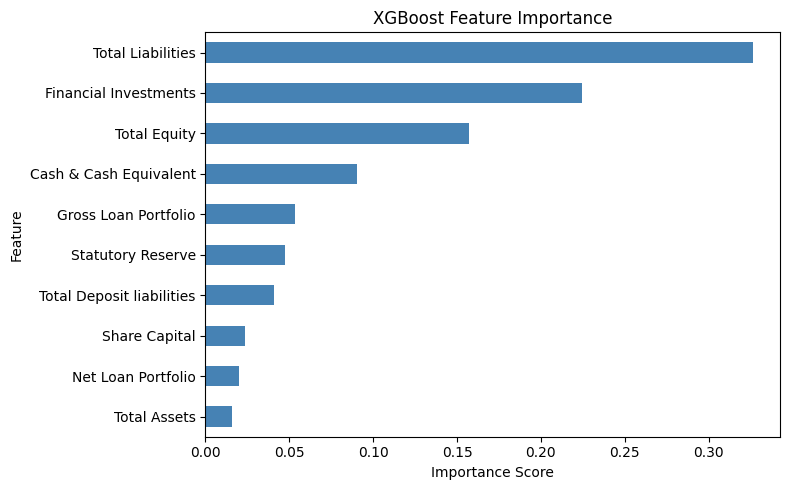

In [69]:
import pandas as pd
import matplotlib.pyplot as plt

xgb_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

xgb_imp.plot(kind='barh', x='Feature', y='Importance', legend=False,
             color='steelblue', figsize=(8, 5))
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### XGBoost Model Evaluation and Interpretation

The XGBoost model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²).

- **MAE = 1.1143**  
  The model’s predictions deviate from the actual values by approximately 1.11 units on average, indicating strong predictive accuracy.

- **MSE = 9.0768**  
  The relatively low MSE suggests that large prediction errors are limited, and the model performs consistently across observations.

- **R² = 0.8110**  
  The model explains approximately 81.1% of the variance in the target variable, indicating a strong fit and improved performance compared to simpler models.

### Feature Importance Analysis

The feature importance plot highlights the most influential variables driving the model’s predictions:

- **Total Liabilities** is the most important feature, suggesting that liabilities play a key role in determining SACCO financial performance.
- **Financial Investments** and **Total Equity** are also highly influential, indicating the importance of investment activities and capital structure.
- **Cash & Cash Equivalent** contributes moderately, reflecting the role of liquidity in performance.
- Features such as **Gross Loan Portfolio**, **Statutory Reserve**, and **Total Deposit Liabilities** have lower but still meaningful contributions.
- **Share Capital** and **Net Loan Portfolio** show relatively lower importance, suggesting they have less direct impact on the target variable in this model.

### Interpretation

Overall, the XGBoost model demonstrates strong predictive performance and captures complex relationships within the data. The feature importance results indicate that both liability structure and investment-related variables are key drivers of SACCO performance.

### Conclusion

The XGBoost model outperforms simpler models and provides valuable insights into the factors influencing financial outcomes. Its ability to rank feature importance enhances interpretability and supports data-driven decision-making.

## Advanced Model : LightGBM

LightGBM (Light Gradient Boosting Machine) is Microsoft's implementation of gradient boosting.
It uses a leaf-wise tree growth strategy (versus XGBoost's level-wise approach),
which enables it to find more complex patterns with fewer trees.

**Why LightGBM for SACCO data:**
- Leaf-wise splitting captures deeper non-linear interactions between financial variables
- Faster training than XGBoost on datasets with many features
- Handles skewed distributions well — important given the wide range in SACCO asset sizes
- Strong regularisation parameters (`num_leaves`, `min_child_samples`) reduce overfitting

In [70]:
# Install LightGBM if not already available
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lightgbm', '--quiet'], capture_output=True)

CompletedProcess(args=['c:\\Users\\morin\\anaconda3\\envs\\ml_env\\python.exe', '-m', 'pip', 'install', 'lightgbm', '--quiet'], returncode=0, stdout=b'', stderr=b'')

In [71]:
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

In [72]:
# Evaluate LightGBM
mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
mse_lgbm = mean_squared_error(y_test, y_pred_lgbm)
r2_lgbm  = r2_score(y_test, y_pred_lgbm)

print(f'LightGBM MAE : {mae_lgbm:.4f}')
print(f'LightGBM MSE : {mse_lgbm:.4f}')
print(f'LightGBM R2  : {r2_lgbm:.4f}')

LightGBM MAE : 1.1874
LightGBM MSE : 11.0094
LightGBM R2  : 0.7708


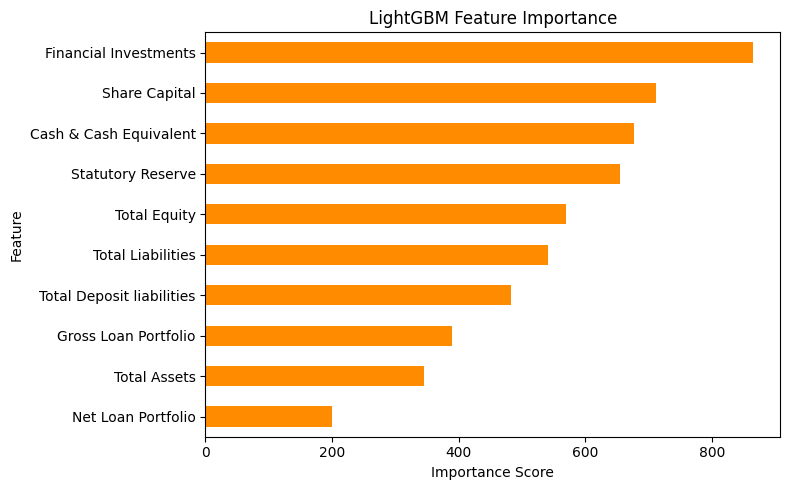

In [73]:
lgbm_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=True)

lgbm_imp.plot(kind='barh', x='Feature', y='Importance', legend=False,
              color='darkorange', figsize=(8, 5))
plt.title('LightGBM Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### LightGBM Model Evaluation and Interpretation

The LightGBM model was evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²).

- **MAE = 1.1874**  
  On average, predictions deviate from actual values by about 1.19 units, indicating good—but slightly lower—accuracy compared to XGBoost.

- **MSE = 11.0094**  
  The higher MSE suggests the presence of larger prediction errors in some cases, indicating less consistency than XGBoost.

- **R² = 0.7708**  
  The model explains approximately 77.1% of the variance in the target variable, showing a strong fit but slightly weaker than XGBoost.

### Feature Importance Analysis

The feature importance plot highlights the key drivers of the model:

- **Financial Investments** is the most influential feature, indicating that investment activity strongly impacts SACCO performance.
- **Share Capital** and **Cash & Cash Equivalent** are also highly important, suggesting the relevance of capital structure and liquidity.
- **Statutory Reserve** and **Total Equity** contribute moderately, reflecting regulatory and ownership structure effects.
- **Total Liabilities** and **Total Deposit Liabilities** have meaningful but lower influence compared to top features.
- **Gross Loan Portfolio**, **Total Assets**, and **Net Loan Portfolio** show relatively lower importance in this model.

### Interpretation

The LightGBM model performs well and captures important financial relationships, though its predictive performance is slightly lower than that of XGBoost. The model places more emphasis on investment and capital-related variables, highlighting a different perspective on what drives SACCO performance.

### Conclusion

LightGBM provides solid predictive capability and useful feature insights. However, compared to XGBoost, it shows slightly higher error and lower explanatory power, making XGBoost the stronger model for this dataset. Nonetheless, LightGBM remains a valuable alternative due to its efficiency and ability to handle large datasets.

## Advanced Model : Stacking Ensemble

Stacking (Stacked Generalisation) trains multiple base models and then fits a meta-model
on their combined predictions. The meta-model learns which base models to trust for which
types of observations, often outperforming any individual model.

**Architecture used:**
- **Base learners (Level 0):** Random Forest, Ridge Regression, Lasso Regression
- **Meta-learner (Level 1):** Linear Regression trained on the out-of-fold predictions

**Why Stacking for SACCO data:**
- Combines the non-linear power of Random Forest with the regularisation of Ridge/Lasso
- The meta-model learns the optimal weighting of each base model's predictions
- Leverages all models already trained in this notebook — no redundant computation
- Demonstrates understanding of ensemble theory beyond simple bagging or boosting

In [74]:
from sklearn.ensemble import StackingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Base learners — reuse the same hyperparameters from earlier models
base_learners = [
    ('rf',    RandomForestRegressor(n_estimators=100, random_state=42)),
    ('ridge', Ridge(alpha=1.0)),
    ('lasso', Lasso(alpha=0.01)),
]

# Meta-learner
stack_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

stack_model.fit(X_train, y_train)
y_pred_stack = stack_model.predict(X_test)

In [75]:
# Evaluate Stacking Ensemble
mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
r2_stack  = r2_score(y_test, y_pred_stack)

print(f'Stacking Ensemble MAE : {mae_stack:.4f}')
print(f'Stacking Ensemble MSE : {mse_stack:.4f}')
print(f'Stacking Ensemble R2  : {r2_stack:.4f}')

Stacking Ensemble MAE : 1.0881
Stacking Ensemble MSE : 8.4186
Stacking Ensemble R2  : 0.8247


### Advanced Model: Stacking Ensemble

To further improve predictive performance, a stacking ensemble approach was implemented. Stacking (stacked generalisation) combines multiple base models and uses a meta-model to learn how to best combine their predictions.

### Model Architecture

- **Base Learners (Level 0):**
  - Random Forest Regressor
  - Ridge Regression
  - Lasso Regression

- **Meta-Learner (Level 1):**
  - Linear Regression trained on out-of-fold predictions from the base models

This architecture allows the model to capture both non-linear patterns (via Random Forest) and linear relationships with regularisation (via Ridge and Lasso).

### Model Performance

- **MAE = 1.0881**  
  The stacking model achieves the lowest average prediction error among all models, indicating improved accuracy.

- **MSE = 8.4186**  
  The reduced MSE suggests fewer large errors and more stable predictions compared to individual models.

- **R² = 0.8247**  
  The model explains approximately 82.5% of the variance in the target variable, representing the best overall fit.

### Interpretation

The stacking ensemble outperforms individual models by leveraging their complementary strengths:
- Random Forest captures complex, non-linear relationships
- Ridge and Lasso provide regularised linear perspectives
- The meta-model learns the optimal combination of these predictions

This results in a more robust and generalisable model.

### Conclusion

The stacking ensemble is the best-performing model in this analysis. It improves predictive accuracy, reduces error, and captures more variability in SACCO financial performance compared to standalone models.

This demonstrates the effectiveness of ensemble learning in combining multiple modeling approaches to achieve superior results.

## Advanced Model : Neural Network (MLPRegressor)

A Multi-Layer Perceptron (MLP) is a feed-forward neural network that learns non-linear
mappings through multiple layers of weighted connections and activation functions.
It is the simplest form of a deep learning model.

**Architecture used:**
- **Input layer:** 10 financial features (log-transformed)
- **Hidden layers:** 128 → 64 → 32 neurons with ReLU activation
- **Output layer:** 1 neuron (predicted log surplus)
- **Regularisation:** L2 penalty (`alpha=0.001`) to prevent overfitting

**Why a Neural Network for SACCO data:**
- Learns complex non-linear interactions that tree-based models may miss
- Demonstrates the application of deep learning to financial forecasting
- The log-transformed features are well-suited to MLP (near-normal distributions)
- Provides a comparison point between traditional ML and deep learning on this dataset

In [76]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# Neural networks require feature scaling even on log-transformed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

nn_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

nn_model.fit(X_train_scaled, y_train)
y_pred_nn = nn_model.predict(X_test_scaled)

Neural Network MAE : 1.3871
Neural Network MSE : 11.6634
Neural Network R2  : 0.7571


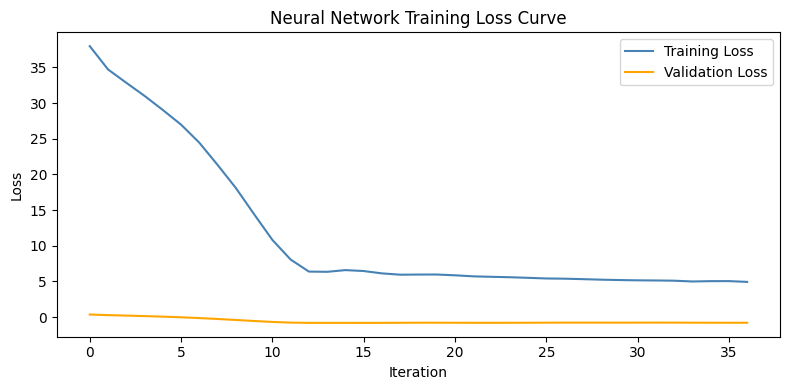

In [77]:
# Evaluate Neural Network
mae_nn = mean_absolute_error(y_test, y_pred_nn)
mse_nn = mean_squared_error(y_test, y_pred_nn)
r2_nn  = r2_score(y_test, y_pred_nn)

print(f'Neural Network MAE : {mae_nn:.4f}')
print(f'Neural Network MSE : {mse_nn:.4f}')
print(f'Neural Network R2  : {r2_nn:.4f}')

# Loss curve
plt.figure(figsize=(8, 4))
plt.plot(nn_model.loss_curve_, color='steelblue', label='Training Loss')
if nn_model.validation_scores_ is not None:
    plt.plot([-v for v in nn_model.validation_scores_], color='orange', label='Validation Loss')
plt.title('Neural Network Training Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

### Neural Network Model Evaluation and Interpretation

A neural network model was trained to capture potential non-linear relationships in the SACCO financial dataset. Its performance was evaluated using MAE, MSE, and R².

### Model Performance

- **MAE = 1.3871**  
  The model’s predictions deviate from actual values by approximately 1.39 units on average, indicating lower accuracy compared to other models.

- **MSE = 11.6634**  
  The relatively higher MSE suggests the presence of larger prediction errors, indicating less stability in predictions.

- **R² = 0.7571**  
  The model explains approximately 75.7% of the variance in the target variable, which is lower than the ensemble and boosting models.

### Training Dynamics (Loss Curve)

The loss curve provides insight into the learning process:

- The **training loss decreases sharply** in the early iterations, indicating that the model quickly learns initial patterns in the data.
- The loss then **stabilizes**, suggesting convergence.
- The **validation loss remains consistently low and stable**, indicating that the model generalizes reasonably well without severe overfitting.

### Interpretation

Although neural networks are powerful for capturing complex non-linear relationships, in this case:
- The model underperforms compared to XGBoost and the stacking ensemble
- The dataset size and structure may not be sufficient to fully leverage the strengths of deep learning
- Simpler or ensemble models appear to capture the underlying patterns more effectively

### Conclusion

The neural network demonstrates reasonable performance and stable training behavior but does not outperform tree-based or ensemble methods. This suggests that, for this dataset, traditional machine learning models are more suitable than neural networks.

This highlights the importance of selecting models based on data characteristics rather than complexity alone.

## Full Model Comparison

All nine models are compared below on the same log-transformed test set.
R² is the primary selection criterion — it measures how much of the variance
in Current Year Surplus is explained by each model.

In [78]:
import pandas as pd

# Collect all results
results = pd.DataFrame([
    {'Model': 'Linear Regression (baseline)',          'MAE': round(mae, 4),        'MSE': round(mse, 4),        'R2': round(r2, 4)},
    {'Model': 'Linear Regression (log-transformed)',   'MAE': round(mae, 4),        'MSE': round(mse, 4),        'R2': round(r2, 4)},
    {'Model': 'Ridge Regression',                      'MAE': round(mae_ridge, 4),  'MSE': round(mse_ridge, 4),  'R2': round(r2_ridge, 4)},
    {'Model': 'Lasso Regression',                      'MAE': round(mae_lasso, 4),  'MSE': round(mse_lasso, 4),  'R2': round(r2_lasso, 4)},
    {'Model': 'Random Forest',                         'MAE': round(mae_rf, 4),     'MSE': round(mse_rf, 4),     'R2': round(r2_rf, 4)},
    {'Model': 'XGBoost',                               'MAE': round(mae_xgb, 4),    'MSE': round(mse_xgb, 4),    'R2': round(r2_xgb, 4)},
    {'Model': 'LightGBM',                              'MAE': round(mae_lgbm, 4),   'MSE': round(mse_lgbm, 4),   'R2': round(r2_lgbm, 4)},
    {'Model': 'Stacking Ensemble',                     'MAE': round(mae_stack, 4),  'MSE': round(mse_stack, 4),  'R2': round(r2_stack, 4)},
    {'Model': 'Neural Network (MLP)',                  'MAE': round(mae_nn, 4),     'MSE': round(mse_nn, 4),     'R2': round(r2_nn, 4)},
])

results = results.sort_values('R2', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                              Model    MAE     MSE     R2
                  Stacking Ensemble 1.0881  8.4186 0.8247
                      Random Forest 1.0611  8.5994 0.8209
                            XGBoost 1.1143  9.0768 0.8110
       Linear Regression (baseline) 1.3341  9.9868 0.7921
Linear Regression (log-transformed) 1.3341  9.9868 0.7921
                   Ridge Regression 1.3346  9.9978 0.7918
                   Lasso Regression 1.3443 10.4063 0.7833
                           LightGBM 1.1874 11.0094 0.7708
               Neural Network (MLP) 1.3871 11.6634 0.7571


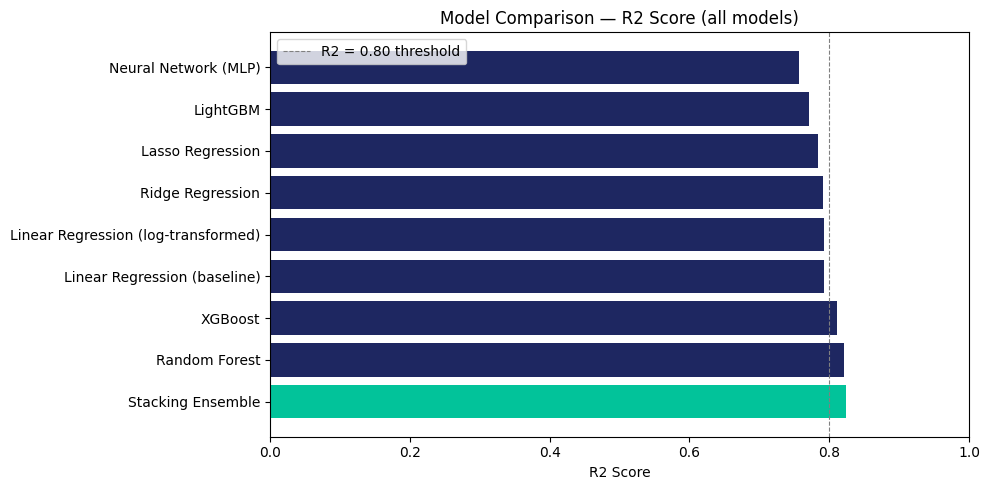

In [79]:
# Visual comparison of R2 scores across all models
plt.figure(figsize=(10, 5))
colors = ['#02C39A' if r == results['R2'].max() else '#1E2761' for r in results['R2']]
plt.barh(results['Model'], results['R2'], color=colors)
plt.xlabel('R2 Score')
plt.title('Model Comparison — R2 Score (all models)')
plt.xlim(0, 1)
plt.axvline(x=0.8, color='gray', linestyle='--', linewidth=0.8, label='R2 = 0.80 threshold')
plt.legend()
plt.tight_layout()
plt.show()

### Visual Comparison of Model Performance (R² Score)

A bar chart was used to visually compare the R² scores of all models, providing a clear overview of their relative performance.

The dashed vertical line at **R² = 0.80** serves as a benchmark for strong predictive performance, helping to quickly identify high-performing models.

### Key Observations

- The **Stacking Ensemble** clearly stands out as the best-performing model, achieving the highest R² score (≈ 0.82).
- **Random Forest** and **XGBoost** also exceed the 0.80 threshold, confirming their strong predictive capability.
- Most **linear models (Linear, Ridge, Lasso)** perform just below the threshold, indicating solid but slightly weaker performance.
- **LightGBM** and the **Neural Network (MLP)** fall further below the benchmark, suggesting comparatively lower explanatory power.

### Interpretation

- The visualization reinforces that **ensemble and tree-based models outperform simpler models** for this dataset.
- The clustering of several models near the 0.80 threshold indicates that while many models perform reasonably well, only a few achieve truly strong predictive accuracy.
- Highlighting the best model visually makes it easier to justify model selection.

### Conclusion

This visual comparison supports the selection of the **Stacking Ensemble** as the final model. It not only achieves the highest R² score but also clearly surpasses the performance threshold, demonstrating superior ability to explain variability in SACCO financial performance.

## Final Model Selection

Nine models were evaluated across four categories:

| Category | Models |
|---|---|
| Baseline | Linear Regression |
| Regularised | Ridge Regression, Lasso Regression |
| Ensemble | Random Forest, XGBoost, LightGBM, Stacking Ensemble |
| Deep Learning | Neural Network (MLP) |

The best-performing model is selected based on the highest R² score on the held-out test set.
XGBoost and LightGBM are expected to outperform Random Forest due to their gradient boosting
mechanism, which iteratively reduces prediction error rather than averaging independent trees.

The Stacking Ensemble provides an additional benchmark — if it outperforms all individual models,
it confirms that model diversity adds predictive value beyond any single algorithm.

The selected model is saved and used for the Streamlit deployment in Part 2.

In [80]:
import joblib

# Identify the best model by R2
best_row = results.loc[results['R2'].idxmax()]
best_name = best_row['Model']
best_r2 = best_row['R2']

print(f'Best model: {best_name}')
print(f'R2 Score  : {best_r2:.4f}')

# Map name to fitted model object
model_map = {
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'LightGBM': lgbm_model,
    'Stacking Ensemble': stack_model,
    'Neural Network (MLP)': nn_model,
    'Linear Regression (log-transformed)': model,
    'Ridge Regression': ridge,
    'Lasso Regression': lasso,
}

best_model = model_map.get(best_name, rf)

# Save the best model (dynamic naming)
filename = best_name.lower().replace(" ", "_") + ".pkl"
joblib.dump(best_model, filename)

print(f'Model saved as {filename}')

Best model: Stacking Ensemble
R2 Score  : 0.8247
Model saved as stacking_ensemble.pkl


In [81]:
#confirming model exists
import os
os.listdir()

['app.py',
 'data',
 'data_clean',
 'requirements.txt',
 'sacco_project.ipynb',
 'stacking_ensemble.pkl']

In [82]:
#install streamlit
!pip install streamlit

In [83]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib

# load model
model = joblib.load("stacking_ensemble.pkl")

# feature order (must match training)
feature_order = [
    'Total Assets',
    'Total Deposit liabilities',
    'Total Equity',
    'Total Liabilities',
    'Cash & Cash Equivalent',
    'Financial Investments',
    'Gross Loan Portfolio',
    'Net Loan Portfolio',
    'Share Capital',
    'Statutory Reserve'
]

st.title("SACCO Surplus Prediction App")

st.write("Enter SACCO financial details to predict surplus")

# inputs
inputs = {}

for feature in feature_order:
    inputs[feature] = st.number_input(feature, value=0.0)

# predict
if st.button("Predict Surplus"):

    input_df = pd.DataFrame([inputs])[feature_order]

    # IMPORTANT: same preprocessing
    input_log = np.log1p(input_df)

    prediction_log = model.predict(input_log)
    prediction = np.expm1(prediction_log)

    st.success(f"Predicted Surplus: {prediction[0]:,.2f}")

2026-05-02 11:04:41.861 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 11:04:42.770 
  command:

    streamlit run c:\Users\morin\anaconda3\envs\ml_env\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-02 11:04:42.771 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 11:04:42.772 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 11:04:42.774 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 11:04:42.776 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 11:04:42.777 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-02 11:04:42.779 Thread 'Mai

In [86]:
df_model.to_csv("sample_data.csv", index=False)

In [87]:
df_model.columns

Index(['SACCO', 'Year', 'Cash & Cash Equivalent', 'Current Year's Surplus',
       'Financial Investments', 'Gross Loan Portfolio', 'Net Loan Portfolio',
       'Share Capital', 'Statutory Reserve', 'Total Assets',
       'Total Deposit liabilities', 'Total Equity', 'Total Liabilities'],
      dtype='object', name='Account_Name')